# BIRD Targeted-SFT Training v1 — Qwen2.5-Coder-7B LoRA

This notebook trains a **new LoRA adapter from the untouched original Base model**
using `train_targeted_sft_v1.jsonl`. It does not load or continue the Original-SFT
adapter.

Controlled comparison against Original SFT:

- same Base model and prompt template;
- same LoRA configuration;
- same number of training prompts and one epoch;
- same batch size, optimizer, scheduler, learning rate, seed, and checkpoint cadence;
- same database-isolated general validation set and the same held-out EX checkpoint selector;
- only the training-example sampling distribution changes.

The targeted data manifest is treated as a required experiment contract. The notebook
stops before allocating the model if hashes, evidence policy, split isolation, prompt
counts, or sampling settings do not match Targeted-SFT v1.


## 1. Install dependencies

Run this before importing Transformers/TRL. If Colab asks for a runtime restart, restart once and continue from the next cell.


In [1]:
%pip install -q -U \
    "transformers==5.14.1" \
    "trl==1.9.2" \
    "peft==0.20.0" \
    "datasets" \
    "accelerate" \
    "sentencepiece"

%pip uninstall -y torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 133.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 46.9 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [2]:
import importlib.util
import torch
import peft

print("Torch:", torch.__version__)
print("PEFT:", peft.__version__)
print("torchao found:", importlib.util.find_spec("torchao"))

Torch: 2.11.0+cu128
PEFT: 0.20.0
torchao found: None


## 2. Mount Drive, import packages, and define isolated Targeted-SFT paths

The run uses a new directory and cannot overwrite the Original-SFT adapter.
Verified checkpoints may be resumed only when the dataset and hyperparameter
fingerprint is identical.


In [3]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [4]:
import gc
import hashlib
import importlib.metadata
import json
import os
import random
import re
import shutil
import sqlite3
import subprocess
import time
import zipfile

from collections import Counter, defaultdict
from pathlib import Path
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
from transformers.trainer_utils import get_last_checkpoint
from trl import SFTConfig, SFTTrainer


PROJECT_DIR = Path("/content/drive/MyDrive/bird-text2sql-sft")
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = PROJECT_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"

TARGETED_DATA_DIR = PROCESSED_DIR / "targeted_sft_v1"
TRAIN_PATH = TARGETED_DATA_DIR / "train_targeted_sft_v1.jsonl"
VALIDATION_PATH = TARGETED_DATA_DIR / "validation_general_sft_v1.jsonl"
TARGETED_VALIDATION_PATH = TARGETED_DATA_DIR / "validation_targeted_sft_v1.jsonl"
TARGETED_MANIFEST_PATH = TARGETED_DATA_DIR / "targeted_sft_manifest_v1.json"
SPLIT_METADATA_PATH = PROCESSED_DIR / "split_metadata_v2.json"

ORIGINAL_SFT_RUN_NAME = (
    "qwen2.5-coder-7b-bf16-lora-sft-v2-filtered-"
    "mixed-evidence-lr2e-5-len8192"
)
RUN_NAME = (
    "qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-"
    "lr2e-5-len8192"
)
RUN_DIR = PROJECT_DIR / "training" / RUN_NAME
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
ADAPTER_DIR = RUN_DIR / "final_adapter"
LOG_DIR = RUN_DIR / "logs"

TRAIN_ZIP_PATH = DATA_DIR / "bird_train.zip"
LOCAL_ZIP = Path("/content/bird_train.zip")
LOCAL_DATA = Path("/content/bird_data")

for directory in [RESULTS_DIR, RUN_DIR, CHECKPOINT_DIR, ADAPTER_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

required_paths = [
    TRAIN_PATH,
    VALIDATION_PATH,
    TARGETED_VALIDATION_PATH,
    TARGETED_MANIFEST_PATH,
    SPLIT_METADATA_PATH,
    TRAIN_ZIP_PATH,
]
for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(f"Required file not found: {required_path}")

print("Project directory:", PROJECT_DIR)
print("Targeted train file:", TRAIN_PATH)
print("General validation file:", VALIDATION_PATH)
print("Targeted diagnostic validation:", TARGETED_VALIDATION_PATH)
print("Targeted manifest:", TARGETED_MANIFEST_PATH)
print("Fresh Targeted-SFT run directory:", RUN_DIR)


Project directory: /content/drive/MyDrive/bird-text2sql-sft
Targeted train file: /content/drive/MyDrive/bird-text2sql-sft/processed/targeted_sft_v1/train_targeted_sft_v1.jsonl
General validation file: /content/drive/MyDrive/bird-text2sql-sft/processed/targeted_sft_v1/validation_general_sft_v1.jsonl
Targeted diagnostic validation: /content/drive/MyDrive/bird-text2sql-sft/processed/targeted_sft_v1/validation_targeted_sft_v1.jsonl
Targeted manifest: /content/drive/MyDrive/bird-text2sql-sft/processed/targeted_sft_v1/targeted_sft_manifest_v1.json
Fresh Targeted-SFT run directory: /content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192


## 3. Verify the GPU and record software versions


In [5]:
if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU is required. In Colab, select an A100 runtime first.")

GPU_NAME = torch.cuda.get_device_name(0)
BF16_SUPPORTED = torch.cuda.is_bf16_supported()

print("GPU:", GPU_NAME)
print("BF16 supported:", BF16_SUPPORTED)
print("Total GPU memory: %.2f GB" % (
    torch.cuda.get_device_properties(0).total_memory / 1024**3
))

if not BF16_SUPPORTED:
    raise RuntimeError("This notebook is configured for BF16 LoRA training.")

package_names = [
    "torch",
    "transformers",
    "trl",
    "peft",
    "datasets",
    "accelerate",
]

package_versions = {
    name: importlib.metadata.version(name)
    for name in package_names
}

print(json.dumps(package_versions, indent=2))


GPU: NVIDIA A100-SXM4-40GB
BF16 supported: True
Total GPU memory: 39.49 GB
{
  "torch": "2.11.0+cu128",
  "transformers": "5.14.1",
  "trl": "1.9.2",
  "peft": "0.20.0",
  "datasets": "5.0.1",
  "accelerate": "1.14.0"
}


## 4. Load data and enforce the Targeted-SFT manifest contract

The general validation set is used for validation loss and checkpoint selection.
The targeted validation set is loaded for a final capability-loss diagnostic only.


In [6]:
data_files = {
    "train": str(TRAIN_PATH),
    "validation": str(VALIDATION_PATH),
    "targeted_validation": str(TARGETED_VALIDATION_PATH),
}

raw_datasets = load_dataset("json", data_files=data_files)
train_dataset = raw_datasets["train"]
validation_dataset = raw_datasets["validation"]
targeted_validation_dataset = raw_datasets["targeted_validation"]


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


TRAIN_SHA256 = sha256_file(TRAIN_PATH)
VALIDATION_SHA256 = sha256_file(VALIDATION_PATH)
TARGETED_VALIDATION_SHA256 = sha256_file(TARGETED_VALIDATION_PATH)
TARGETED_MANIFEST_SHA256 = sha256_file(TARGETED_MANIFEST_PATH)

split_metadata = json.loads(SPLIT_METADATA_PATH.read_text(encoding="utf-8"))
targeted_manifest = json.loads(
    TARGETED_MANIFEST_PATH.read_text(encoding="utf-8")
)

if targeted_manifest.get("version") != "bird_targeted_sft_v1":
    raise RuntimeError(
        "Expected manifest version bird_targeted_sft_v1, found "
        f"{targeted_manifest.get('version')!r}."
    )

expected_output_hashes = {
    TRAIN_PATH.name: TRAIN_SHA256,
    VALIDATION_PATH.name: VALIDATION_SHA256,
    TARGETED_VALIDATION_PATH.name: TARGETED_VALIDATION_SHA256,
}
manifest_outputs = targeted_manifest.get("outputs", {})
for file_name, actual_hash in expected_output_hashes.items():
    expected_hash = manifest_outputs.get(file_name, {}).get("sha256")
    if expected_hash != actual_hash:
        raise RuntimeError(
            f"Manifest hash mismatch for {file_name}: "
            f"expected {expected_hash}, actual {actual_hash}."
        )

EXPECTED_TARGETED_SHARE = 0.65
EXPECTED_GENERAL_REPLAY_SHARE = 0.35
EXPECTED_FAMILY_WEIGHTS = {
    "schema_relationship": 0.40,
    "predicate_evidence": 0.22,
    "computation_logic": 0.20,
    "result_structure": 0.18,
}
EXPECTED_FORCE_EVIDENCE = False

sampling_manifest = targeted_manifest.get("sampling", {})
if not np.isclose(
    float(sampling_manifest.get("targeted_share", -1)),
    EXPECTED_TARGETED_SHARE,
):
    raise RuntimeError("Targeted share differs from the controlled v1 design.")
if not np.isclose(
    float(sampling_manifest.get("general_replay_share", -1)),
    EXPECTED_GENERAL_REPLAY_SHARE,
):
    raise RuntimeError("General replay share differs from the controlled v1 design.")
if sampling_manifest.get("family_weights") != EXPECTED_FAMILY_WEIGHTS:
    raise RuntimeError("Target-family weights differ from the controlled v1 design.")
if bool(sampling_manifest.get("force_evidence_for_targeted")) is not EXPECTED_FORCE_EVIDENCE:
    raise RuntimeError(
        "This notebook isolates targeted sampling and expects "
        "force_evidence_for_targeted=False. Run forced Evidence as a separate ablation."
    )

expected_train_prompts = int(split_metadata["training_prompt_count"])
expected_validation_prompts = int(split_metadata["validation_prompt_count"])
if len(train_dataset) != expected_train_prompts:
    raise RuntimeError(
        f"Expected {expected_train_prompts} targeted train prompts, "
        f"found {len(train_dataset)}."
    )
if len(validation_dataset) != expected_validation_prompts:
    raise RuntimeError(
        f"Expected {expected_validation_prompts} general validation prompts, "
        f"found {len(validation_dataset)}."
    )
if int(sampling_manifest.get("output_train_prompts", -1)) != len(train_dataset):
    raise RuntimeError("Manifest training count does not match the JSONL file.")

print("Targeted train prompts:", len(train_dataset))
print("General validation prompts:", len(validation_dataset))
print("Targeted diagnostic prompts:", len(targeted_validation_dataset))
print("Targeted family quotas:", sampling_manifest.get("family_quotas"))
print("Unique train-source coverage:", f"{sampling_manifest.get('unique_source_coverage', 0):.1%}")
print("Output Evidence rate:", f"{sampling_manifest.get('output_evidence_rate', 0):.1%}")
print("Train SHA256:", TRAIN_SHA256)
print("General validation SHA256:", VALIDATION_SHA256)
print("Targeted validation SHA256:", TARGETED_VALIDATION_SHA256)


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating targeted_validation split: 0 examples [00:00, ? examples/s]

Targeted train prompts: 5825
General validation prompts: 1485
Targeted diagnostic prompts: 775
Targeted family quotas: {'schema_relationship': 1514, 'predicate_evidence': 833, 'computation_logic': 757, 'result_structure': 682}
Unique train-source coverage: 77.8%
Output Evidence rate: 50.9%
Train SHA256: 130acd76b8c507d4b3c49d58dd70bad460585290eaa6af5e9399c0ecb73e7bd2
General validation SHA256: b3d6ba724d3135c4653fd36369b0c7052cca231b09e02b6b436a739cf41ea68e
Targeted validation SHA256: d5e60523acd09ee90d0e0b9f03b01943039ccaf78fa35a02bee4fc43b799a818


In [7]:
EXPECTED_ROLES = ["system", "user", "assistant"]
EXPECTED_PROMPT_VERSION = "bird_schema_evidence_ablation_chat_v2"


def validate_example(example, split_name, index):
    if not isinstance(example.get("source_index"), int):
        raise ValueError(f"{split_name}[{index}] has an invalid source_index")

    if not isinstance(example.get("db_id"), str) or not example["db_id"].strip():
        raise ValueError(f"{split_name}[{index}] has an invalid db_id")

    if not isinstance(example.get("use_evidence"), bool):
        raise ValueError(f"{split_name}[{index}] has an invalid use_evidence flag")

    if example.get("prompt_version") != EXPECTED_PROMPT_VERSION:
        raise ValueError(f"{split_name}[{index}] has the wrong prompt version")

    messages = example.get("messages")
    if not isinstance(messages, list) or len(messages) != 3:
        raise ValueError(f"{split_name}[{index}] must contain exactly 3 messages")

    roles = [message.get("role") for message in messages]
    if roles != EXPECTED_ROLES:
        raise ValueError(
            f"{split_name}[{index}] has roles {roles}, expected {EXPECTED_ROLES}"
        )

    for message_index, message in enumerate(messages):
        content = message.get("content")
        if not isinstance(content, str) or not content.strip():
            raise ValueError(
                f"{split_name}[{index}].messages[{message_index}] has empty content"
            )

    evidence = str(example.get("evidence") or "").strip()
    expected_evidence_block = (
        evidence if example["use_evidence"] and evidence else "None"
    )
    if f"External knowledge:\n{expected_evidence_block}\n" not in messages[1]["content"]:
        raise ValueError(f"{split_name}[{index}] has an inconsistent Evidence block")


datasets_to_validate = [
    ("train", train_dataset),
    ("validation_general", validation_dataset),
    ("validation_targeted", targeted_validation_dataset),
]
for split_name, dataset in datasets_to_validate:
    for index, example in enumerate(dataset):
        validate_example(example, split_name, index)

print("All records passed schema, role, prompt-version, and Evidence validation.")
print("Example target role:", train_dataset[0].get("selection_role"))
print("Example target family:", train_dataset[0].get("target_family"))
print("Example Gold SQL:", train_dataset[0]["messages"][-1]["content"])


All records passed schema, role, prompt-version, and Evidence validation.
Example target role: general_replay
Example target family: general_replay
Example Gold SQL: SELECT T1.grade_level FROM projects AS T1 INNER JOIN essays AS T2 ON T1.projectid = T2.projectid WHERE T2.title LIKE 'Too Close for Comfort'


## 5. Verify database isolation, controlled duplication, and validation provenance


In [8]:
def stable_hash(value):
    encoded = json.dumps(
        value,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()


def full_record_key(example):
    return stable_hash({
        "db_id": example["db_id"],
        "messages": example["messages"],
    })


train_record_keys = {full_record_key(example) for example in train_dataset}
validation_record_keys = {
    full_record_key(example) for example in validation_dataset
}
train_db_ids = set(train_dataset["db_id"])
validation_db_ids = set(validation_dataset["db_id"])
targeted_validation_db_ids = set(targeted_validation_dataset["db_id"])
train_source_indices = set(train_dataset["source_index"])
validation_source_indices = set(validation_dataset["source_index"])
targeted_validation_source_indices = set(
    targeted_validation_dataset["source_index"]
)

exact_record_overlap = train_record_keys & validation_record_keys
database_overlap = train_db_ids & validation_db_ids
source_overlap = train_source_indices & validation_source_indices

if exact_record_overlap or database_overlap or source_overlap:
    raise RuntimeError("Train/general-validation leakage was detected.")
if not targeted_validation_source_indices <= validation_source_indices:
    raise RuntimeError(
        "Targeted diagnostic validation is not a subset of held-out validation sources."
    )
if not targeted_validation_db_ids <= validation_db_ids:
    raise RuntimeError(
        "Targeted diagnostic validation contains a non-validation database."
    )

source_occurrences = Counter(int(value) for value in train_dataset["source_index"])
observed_max_occurrences = max(source_occurrences.values())
unique_source_coverage = len(source_occurrences) / int(
    split_metadata["training_source_count"]
)
manifest_max_occurrences = int(
    sampling_manifest.get("max_source_occurrences", -1)
)
manifest_unique_coverage = float(
    sampling_manifest.get("unique_source_coverage", -1)
)

if observed_max_occurrences > manifest_max_occurrences:
    raise RuntimeError("A training source exceeds the manifest occurrence cap.")
if not np.isclose(unique_source_coverage, manifest_unique_coverage):
    raise RuntimeError("Observed unique-source coverage differs from the manifest.")

selection_frame = pd.DataFrame({
    "selection_role": train_dataset["selection_role"],
    "target_family": train_dataset["target_family"],
    "use_evidence": train_dataset["use_evidence"],
    "db_id": train_dataset["db_id"],
})

print("Exact record overlap:", len(exact_record_overlap))
print("Database overlap:", len(database_overlap))
print("Source-index overlap:", len(source_overlap))
print("Unique targeted-train sources:", len(source_occurrences))
print("Unique source coverage:", f"{unique_source_coverage:.1%}")
print("Maximum source occurrences:", observed_max_occurrences)
print("Targeted validation is held-out subset:", True)
print("Selection-role counts:")
print(selection_frame["selection_role"].value_counts())
print("Target-family counts:")
print(selection_frame["target_family"].value_counts())
print("Evidence rate by role:")
print(selection_frame.groupby("selection_role")["use_evidence"].mean())


Exact record overlap: 0
Database overlap: 0
Source-index overlap: 0
Unique targeted-train sources: 4531
Unique source coverage: 77.8%
Maximum source occurrences: 2
Targeted validation is held-out subset: True
Selection-role counts:
selection_role
targeted          3786
general_replay    2039
Name: count, dtype: int64
Target-family counts:
target_family
general_replay         2039
schema_relationship    1514
predicate_evidence      833
computation_logic       757
result_structure        682
Name: count, dtype: int64
Evidence rate by role:
selection_role
general_replay    0.486513
targeted          0.521395
Name: use_evidence, dtype: float64


## 6. Load the tokenizer and verify 8,192-token coverage

The Original-SFT and Targeted-SFT comparison uses the same 8,192-token limit.
Training stops before model loading if any Gold conversation would be truncated.


In [9]:
MODEL_ID = "Qwen/Qwen2.5-Coder-7B-Instruct"
MAX_LENGTH = 8192
SEED = 42

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    use_fast=True,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

print("Model:", MODEL_ID)
print("MAX_LENGTH:", MAX_LENGTH)
print("EOS token:", tokenizer.eos_token, tokenizer.eos_token_id)
print("PAD token:", tokenizer.pad_token, tokenizer.pad_token_id)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Model: Qwen/Qwen2.5-Coder-7B-Instruct
MAX_LENGTH: 8192
EOS token: <|im_end|> 151645
PAD token: <|endoftext|> 151643


In [10]:
def token_length(example):
    token_ids = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=True,
        add_generation_prompt=False,
    )
    return len(token_ids)


length_sets = {
    "Targeted train": np.array([token_length(example) for example in train_dataset]),
    "General validation": np.array([
        token_length(example) for example in validation_dataset
    ]),
    "Targeted validation": np.array([
        token_length(example) for example in targeted_validation_dataset
    ]),
}


def print_length_summary(name, values):
    print(name)
    for percentile in [50, 90, 95, 99, 100]:
        print(
            f"  p{percentile}: "
            f"{int(np.percentile(values, percentile))} tokens"
        )
    overflow = int((values > MAX_LENGTH).sum())
    print(
        f"  Over {MAX_LENGTH}: {overflow}/{len(values)} "
        f"({overflow / len(values):.2%})"
    )


for name, values in length_sets.items():
    print_length_summary(name, values)

overflow_count = sum(
    int((values > MAX_LENGTH).sum()) for values in length_sets.values()
)
if overflow_count:
    raise RuntimeError(
        f"{overflow_count} records exceed MAX_LENGTH={MAX_LENGTH}. "
        "Do not train with silent truncation."
    )

print("No record will be truncated at MAX_LENGTH =", MAX_LENGTH)


Targeted train
  p50: 2 tokens
  p90: 2 tokens
  p95: 2 tokens
  p99: 2 tokens
  p100: 2 tokens
  Over 8192: 0/5825 (0.00%)
General validation
  p50: 2 tokens
  p90: 2 tokens
  p95: 2 tokens
  p99: 2 tokens
  p100: 2 tokens
  Over 8192: 0/1485 (0.00%)
Targeted validation
  p50: 2 tokens
  p90: 2 tokens
  p95: 2 tokens
  p99: 2 tokens
  p100: 2 tokens
  Over 8192: 0/775 (0.00%)
No record will be truncated at MAX_LENGTH = 8192


## 7. Keep general validation as the checkpoint-selection objective

The complete database-isolated general validation set remains the Trainer evaluation
dataset. This avoids selecting a checkpoint only because it fits the targeted subset.
`validation_targeted_sft_v1.jsonl` is evaluated after training as a secondary diagnostic.


In [11]:
loss_validation_dataset = validation_dataset

condition_frame = pd.DataFrame({
    "db_id": validation_dataset["db_id"],
    "source_index": validation_dataset["source_index"],
    "use_evidence": validation_dataset["use_evidence"],
})
targeted_condition_frame = pd.DataFrame({
    "db_id": targeted_validation_dataset["db_id"],
    "source_index": targeted_validation_dataset["source_index"],
    "use_evidence": targeted_validation_dataset["use_evidence"],
    "target_family": targeted_validation_dataset["target_family"],
})

print("General validation prompts:", len(loss_validation_dataset))
print("General validation source questions:", condition_frame["source_index"].nunique())
print("General validation databases:", condition_frame["db_id"].nunique())
print("General validation condition counts:")
print(condition_frame["use_evidence"].value_counts().sort_index())
print("Targeted diagnostic prompts:", len(targeted_validation_dataset))
print("Targeted diagnostic family counts:")
print(targeted_condition_frame["target_family"].value_counts())


General validation prompts: 1485
General validation source questions: 776
General validation databases: 7
General validation condition counts:
use_evidence
False    776
True     709
Name: count, dtype: int64
Targeted diagnostic prompts: 775
Targeted diagnostic family counts:
target_family
schema_relationship    629
predicate_evidence     117
result_structure        21
computation_logic        8
Name: count, dtype: int64


## 8. Convert to conversational prompt/completion format

This leaves the JSONL files unchanged. In TRL, prompt/completion data uses completion-only loss by default; we also set it explicitly in `SFTConfig`.


In [12]:
def to_prompt_completion(example):
    return {
        "prompt": example["messages"][:-1],
        "completion": [example["messages"][-1]],
    }


train_sft_dataset = train_dataset.map(
    to_prompt_completion,
    remove_columns=train_dataset.column_names,
    desc="Converting Targeted-SFT training records",
)
eval_sft_dataset = loss_validation_dataset.map(
    to_prompt_completion,
    remove_columns=loss_validation_dataset.column_names,
    desc="Converting general validation records",
)
targeted_eval_sft_dataset = targeted_validation_dataset.map(
    to_prompt_completion,
    remove_columns=targeted_validation_dataset.column_names,
    desc="Converting targeted diagnostic validation records",
)

print("Training columns:", train_sft_dataset.column_names)
print("General evaluation columns:", eval_sft_dataset.column_names)
print("Targeted evaluation columns:", targeted_eval_sft_dataset.column_names)
print("Prompt roles:", [m["role"] for m in train_sft_dataset[0]["prompt"]])
print("Completion roles:", [m["role"] for m in train_sft_dataset[0]["completion"]])


Converting Targeted-SFT training records:   0%|          | 0/5825 [00:00<?, ? examples/s]

Converting general validation records:   0%|          | 0/1485 [00:00<?, ? examples/s]

Converting targeted diagnostic validation records:   0%|          | 0/775 [00:00<?, ? examples/s]

Training columns: ['prompt', 'completion']
General evaluation columns: ['prompt', 'completion']
Targeted evaluation columns: ['prompt', 'completion']
Prompt roles: ['system', 'user']
Completion roles: ['assistant']


## 9. Load the original BF16 Base model and attach a fresh LoRA adapter

No Original-SFT checkpoint or adapter is loaded in this section.


In [13]:
gc.collect()
torch.cuda.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    attn_implementation="sdpa",
    low_cpu_mem_usage=True,
)

model.config.use_cache = False
model.enable_input_require_grads()

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


## 10. Configure the controlled Targeted-SFT run

These hyperparameters match the Original-SFT comparison run. Since the targeted
training file has the same prompt count, one epoch also keeps optimizer steps aligned.


In [14]:
training_args = SFTConfig(
    output_dir=str(CHECKPOINT_DIR),
    run_name=RUN_NAME,

    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=2,

    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    weight_decay=0.01,
    max_grad_norm=1.0,
    optim="adamw_torch_fused",

    bf16=True,
    fp16=False,
    tf32=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    use_cache=False,

    max_length=MAX_LENGTH,
    packing=False,
    eval_packing=False,
    completion_only_loss=True,
    dataset_num_proc=2,

    logging_strategy="steps",
    logging_steps=10,
    logging_first_step=True,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=10,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_only_model=False,

    report_to="none",
    seed=SEED,
    data_seed=SEED,
    include_num_input_tokens_seen=True,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_sft_dataset,
    eval_dataset=eval_sft_dataset,
    processing_class=tokenizer,
)

optimizer_steps_per_epoch = int(np.ceil(
    len(train_sft_dataset)
    / training_args.per_device_train_batch_size
    / training_args.gradient_accumulation_steps
))

print("Trainer created.")
print("Optimizer steps per epoch (approx.):", optimizer_steps_per_epoch)
print("Expected saved checkpoints:", optimizer_steps_per_epoch // training_args.save_steps)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset (num_proc=2):   0%|          | 0/5825 [00:00<?, ? examples/s]

Building labels for train dataset (num_proc=2):   0%|          | 0/5825 [00:00<?, ? examples/s]

Truncating train dataset (num_proc=2):   0%|          | 0/5825 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset (num_proc=2):   0%|          | 0/5825 [00:00<?, ? examples/s…

Tokenizing eval dataset (num_proc=2):   0%|          | 0/1485 [00:00<?, ? examples/s]

Building labels for eval dataset (num_proc=2):   0%|          | 0/1485 [00:00<?, ? examples/s]

Truncating eval dataset (num_proc=2):   0%|          | 0/1485 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset (num_proc=2):   0%|          | 0/1485 [00:00<?, ? examples/s]

Trainer created.
Optimizer steps per epoch (approx.): 729
Expected saved checkpoints: 7


## 11. Verify that only completion tokens receive loss

Do not continue unless `Supervised tokens` is positive and smaller than `Active tokens`.


In [15]:
prepared_example = trainer.train_dataset[0]
verification_batch = trainer.data_collator([prepared_example])

labels = verification_batch["labels"][0]
attention_mask = verification_batch["attention_mask"][0]

active_tokens = int(attention_mask.sum().item())
supervised_tokens = int((labels != -100).sum().item())
masked_prompt_tokens = active_tokens - supervised_tokens

print("Active tokens:", active_tokens)
print("Supervised tokens:", supervised_tokens)
print("Masked prompt tokens:", masked_prompt_tokens)

if not (0 < supervised_tokens < active_tokens):
    raise RuntimeError(
        "Completion-only masking is not working correctly. Do not start training."
    )

print("Completion-only loss masking is working.")


Active tokens: 734
Supervised tokens: 39
Masked prompt tokens: 695
Completion-only loss masking is working.


## 12. Save the run configuration before training

Checkpoints include optimizer/scheduler state, so an interrupted Colab run can resume.


In [16]:
resume_signature = {
    "model_id": MODEL_ID,
    "method": "BF16 LoRA Targeted-SFT v1",
    "comparison_baseline_run_name": ORIGINAL_SFT_RUN_NAME,
    "prompt_version": EXPECTED_PROMPT_VERSION,
    "train_sha256": TRAIN_SHA256,
    "validation_sha256": VALIDATION_SHA256,
    "targeted_validation_sha256": TARGETED_VALIDATION_SHA256,
    "targeted_manifest_sha256": TARGETED_MANIFEST_SHA256,
    "targeted_sampling_version": targeted_manifest["version"],
    "targeted_sampling": sampling_manifest,
    "max_length": MAX_LENGTH,
    "train_records": len(train_sft_dataset),
    "eval_records": len(eval_sft_dataset),
    "targeted_eval_records": len(targeted_eval_sft_dataset),
    "num_train_epochs": training_args.num_train_epochs,
    "per_device_train_batch_size": training_args.per_device_train_batch_size,
    "gradient_accumulation_steps": training_args.gradient_accumulation_steps,
    "learning_rate": training_args.learning_rate,
    "lr_scheduler_type": str(training_args.lr_scheduler_type),
    "warmup_ratio": training_args.warmup_ratio,
    "weight_decay": training_args.weight_decay,
    "lora_r": lora_config.r,
    "lora_alpha": lora_config.lora_alpha,
    "lora_dropout": lora_config.lora_dropout,
    "lora_target_modules": sorted(lora_config.target_modules),
    "seed": SEED,
}

resume_fingerprint = stable_hash(resume_signature)
run_config = {
    **resume_signature,
    "resume_fingerprint": resume_fingerprint,
    "experiment_isolation": (
        "Same Base/LoRA/optimizer/steps/validation as Original SFT; "
        "only the training-example sampling distribution changes."
    ),
    "effective_batch_size": (
        training_args.per_device_train_batch_size
        * training_args.gradient_accumulation_steps
    ),
    "optimizer_steps_per_epoch_approx": optimizer_steps_per_epoch,
    "eval_steps": training_args.eval_steps,
    "save_steps": training_args.save_steps,
    "gpu": GPU_NAME,
    "package_versions": package_versions,
    "train_path": str(TRAIN_PATH),
    "validation_path": str(VALIDATION_PATH),
    "targeted_validation_path": str(TARGETED_VALIDATION_PATH),
    "targeted_manifest_path": str(TARGETED_MANIFEST_PATH),
    "split_metadata_path": str(SPLIT_METADATA_PATH),
}

RUN_CONFIG_PATH = RUN_DIR / "run_config.json"
existing_checkpoint = get_last_checkpoint(str(CHECKPOINT_DIR))

if existing_checkpoint:
    if not RUN_CONFIG_PATH.exists():
        raise RuntimeError(
            "A Targeted-SFT checkpoint exists without run_config.json. "
            "Do not resume an unverifiable run."
        )
    previous_config = json.loads(RUN_CONFIG_PATH.read_text(encoding="utf-8"))
    if previous_config.get("resume_fingerprint") != resume_fingerprint:
        raise RuntimeError(
            "Existing Targeted-SFT checkpoints use different data or "
            "hyperparameters. Change RUN_NAME for a new experiment."
        )

RUN_CONFIG_PATH.write_text(
    json.dumps(run_config, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(json.dumps(run_config, ensure_ascii=False, indent=2))
print("Saved:", RUN_CONFIG_PATH)


{
  "model_id": "Qwen/Qwen2.5-Coder-7B-Instruct",
  "method": "BF16 LoRA Targeted-SFT v1",
  "comparison_baseline_run_name": "qwen2.5-coder-7b-bf16-lora-sft-v2-filtered-mixed-evidence-lr2e-5-len8192",
  "prompt_version": "bird_schema_evidence_ablation_chat_v2",
  "train_sha256": "130acd76b8c507d4b3c49d58dd70bad460585290eaa6af5e9399c0ecb73e7bd2",
  "validation_sha256": "b3d6ba724d3135c4653fd36369b0c7052cca231b09e02b6b436a739cf41ea68e",
  "targeted_validation_sha256": "d5e60523acd09ee90d0e0b9f03b01943039ccaf78fa35a02bee4fc43b799a818",
  "targeted_manifest_sha256": "30282f6109cdc7b214471d02ab9533f42d1a782310e6baa060462547d4104955",
  "targeted_sampling_version": "bird_targeted_sft_v1",
  "targeted_sampling": {
    "seed": 20260816,
    "output_train_prompts": 5825,
    "targeted_share": 0.65,
    "general_replay_share": 0.35,
    "family_weights": {
      "schema_relationship": 0.4,
      "predicate_evidence": 0.22,
      "computation_logic": 0.2,
      "result_structure": 0.18
    },
   

## 13. Train or safely resume the isolated Targeted-SFT run

Only checkpoints with the identical dataset hashes, manifest, and hyperparameter
fingerprint may resume. The run directory is separate from Original SFT.


In [17]:
last_checkpoint = get_last_checkpoint(str(CHECKPOINT_DIR))

if last_checkpoint:
    print("Resuming verified Targeted-SFT run from:", last_checkpoint)
else:
    print("Starting a fresh Targeted-SFT training run from the original Base model.")

torch.cuda.reset_peak_memory_stats()
training_start_time = time.monotonic()

train_result = trainer.train(resume_from_checkpoint=last_checkpoint)

elapsed_seconds = time.monotonic() - training_start_time
peak_gpu_memory_gb = torch.cuda.max_memory_allocated() / 1024**3

print("Targeted-SFT training finished.")
print(f"Elapsed: {elapsed_seconds / 3600:.2f} hours")
print(f"Peak allocated GPU memory: {peak_gpu_memory_gb:.2f} GB")
print("Best general-validation-loss checkpoint:", trainer.state.best_model_checkpoint)
print("Best general validation loss:", trainer.state.best_metric)


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting a fresh Targeted-SFT training run from the original Base model.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy,Input Tokens Seen
100,0.134402,0.113314,0.111035,832630.000000,0.963010,1224464
200,0.141282,0.111631,0.110013,1695943.000000,0.963515,2496870
300,0.111709,0.113354,0.105339,2562553.000000,0.963534,3760060
400,0.106270,0.112685,0.105782,3397357.000000,0.963323,4982482
500,0.105367,0.112056,0.103770,4242374.000000,0.963803,6196264
600,0.097716,0.112276,0.103567,5056267.000000,0.963491,7396882
700,0.121493,0.112326,0.103396,5956386.000000,0.963522,8690660
729,0.099530,0.112339,0.103305,6212949.000000,0.963709,9085043


Targeted-SFT training finished.
Elapsed: 1.42 hours
Peak allocated GPU memory: 24.29 GB
Best general-validation-loss checkpoint: /content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192/checkpoints/checkpoint-200
Best general validation loss: 0.11163096129894257


In [18]:
total_memory_gb = (
    torch.cuda.get_device_properties(0).total_memory / 1024**3
)

print(f"Total GPU memory: {total_memory_gb:.2f} GB")
print(
    "Peak allocated:",
    torch.cuda.max_memory_allocated() / 1024**3,
    "GB",
)
print(
    "Peak reserved:",
    torch.cuda.max_memory_reserved() / 1024**3,
    "GB",
)

Total GPU memory: 39.49 GB
Peak allocated: 24.29136323928833 GB
Peak reserved: 26.0390625 GB


## 14. Select the final checkpoint with the same held-out EX protocol

The general validation databases are excluded from training. The notebook uses the same
deterministic 50-question, balanced no-Evidence/with-Evidence subset and macro EX metric
as the Original-SFT run. Validation loss breaks ties.


In [19]:
# Reuse the extracted training databases when notebook 02 ran in this runtime;
# otherwise reconstruct them from the persistent BIRD archive.
database_files = sorted(LOCAL_DATA.rglob("*.sqlite")) if LOCAL_DATA.exists() else []

if not database_files:
    if not LOCAL_ZIP.exists() or not zipfile.is_zipfile(LOCAL_ZIP):
        shutil.copy2(TRAIN_ZIP_PATH, LOCAL_ZIP)

    LOCAL_DATA.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ["unzip", "-q", "-o", str(LOCAL_ZIP), "-d", str(LOCAL_DATA)],
        check=True,
    )

    nested_archives = sorted(LOCAL_DATA.rglob("train_databases.zip"))
    if len(nested_archives) != 1:
        raise RuntimeError(
            "Expected exactly one train_databases.zip, "
            f"found {len(nested_archives)}."
        )

    inner_zip = nested_archives[0]
    subprocess.run(
        ["unzip", "-q", "-o", str(inner_zip), "-d", str(inner_zip.parent)],
        check=True,
    )
    database_files = sorted(LOCAL_DATA.rglob("*.sqlite"))

database_path_by_id = {}
for db_path in database_files:
    db_id = db_path.stem
    if db_id in database_path_by_id:
        raise RuntimeError(f"Duplicate SQLite database ID: {db_id}")
    database_path_by_id[db_id] = db_path

missing_validation_databases = sorted(
    set(validation_dataset["db_id"]) - set(database_path_by_id)
)
if missing_validation_databases:
    raise RuntimeError(
        "Missing held-out validation databases: "
        + ", ".join(missing_validation_databases)
    )

print("SQLite databases available:", len(database_path_by_id))
print("Held-out validation databases:", len(set(validation_dataset["db_id"])))


SQLite databases available: 138
Held-out validation databases: 7


In [20]:
EX_SELECTION_SOURCE_SIZE = 50
EX_MAX_NEW_TOKENS = 256
EX_SQL_TIMEOUT_SECONDS = 30.0


validation_rows = [dict(example) for example in validation_dataset]
variants_by_source = defaultdict(dict)
db_by_source = {}

for example in validation_rows:
    source_index = int(example["source_index"])
    variants_by_source[source_index][bool(example["use_evidence"])] = example
    db_by_source[source_index] = example["db_id"]

eligible_sources_by_db = defaultdict(list)
for source_index, variants in variants_by_source.items():
    if set(variants) == {False, True}:
        eligible_sources_by_db[db_by_source[source_index]].append(source_index)

selection_rng = random.Random(SEED)
for source_indices in eligible_sources_by_db.values():
    selection_rng.shuffle(source_indices)

# Round-robin sampling guarantees database coverage before adding second items.
selected_source_indices = []
while len(selected_source_indices) < min(
    EX_SELECTION_SOURCE_SIZE,
    sum(len(values) for values in eligible_sources_by_db.values()),
):
    added = False
    for db_id in sorted(eligible_sources_by_db):
        if eligible_sources_by_db[db_id]:
            selected_source_indices.append(
                eligible_sources_by_db[db_id].pop()
            )
            added = True
            if len(selected_source_indices) >= EX_SELECTION_SOURCE_SIZE:
                break
    if not added:
        break

ex_selection_records = []
for source_index in selected_source_indices:
    ex_selection_records.append(variants_by_source[source_index][False])
    ex_selection_records.append(variants_by_source[source_index][True])

print("EX-selection source questions:", len(selected_source_indices))
print("EX-selection prompts:", len(ex_selection_records))
print(
    "EX-selection databases:",
    len({record["db_id"] for record in ex_selection_records}),
)

if len(ex_selection_records) != 2 * len(selected_source_indices):
    raise RuntimeError("The EX checkpoint-selection set is not balanced.")


EX-selection source questions: 50
EX-selection prompts: 100
EX-selection databases: 7


In [21]:
def first_sql_statement(text):
    quote_char = None
    index = 0
    while index < len(text):
        character = text[index]
        if quote_char is None:
            if character in {"'", '"', "`"}:
                quote_char = character
            elif character == ";":
                return text[: index + 1]
        elif character == quote_char:
            if index + 1 < len(text) and text[index + 1] == quote_char:
                index += 1
            else:
                quote_char = None
        index += 1
    return text


def extract_sql(raw_text):
    text = (raw_text or "").strip()
    text = re.sub(
        r"<think>.*?</think>",
        "",
        text,
        flags=re.IGNORECASE | re.DOTALL,
    ).strip()
    fenced = re.search(
        r"```(?:sql|sqlite)?\s*(.*?)```",
        text,
        flags=re.IGNORECASE | re.DOTALL,
    )
    if fenced:
        text = fenced.group(1).strip()
    start = re.search(r"\b(?:SELECT|WITH)\b", text, flags=re.IGNORECASE)
    if start:
        text = text[start.start():]
    return first_sql_statement(text).strip()


def execute_read_only(db_path, sql, timeout_seconds):
    if not sql or not sql.strip():
        return None, "empty SQL"

    deadline = time.perf_counter() + timeout_seconds
    uri = f"file:{quote(str(Path(db_path).resolve()))}?mode=ro"
    connection = None
    try:
        connection = sqlite3.connect(uri, uri=True, timeout=timeout_seconds)
        connection.execute("PRAGMA query_only = ON")
        connection.set_progress_handler(
            lambda: 1 if time.perf_counter() > deadline else 0,
            10_000,
        )
        return connection.execute(sql).fetchall(), ""
    except Exception as error:
        return None, str(error)
    finally:
        if connection is not None:
            connection.close()


def execution_equal(predicted_rows, gold_rows):
    if predicted_rows is None or gold_rows is None:
        return False
    return set(predicted_rows) == set(gold_rows)


def generate_sql(model, prompt_messages):
    model_inputs = tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.get_input_embeddings().weight.device)

    with torch.inference_mode():
        output_ids = model.generate(
            **model_inputs,
            max_new_tokens=EX_MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            use_cache=True,
        )

    new_tokens = output_ids[0, model_inputs["input_ids"].shape[1]:]
    raw_generation = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return raw_generation, extract_sql(raw_generation)


In [ ]:
checkpoint_paths = sorted(
    CHECKPOINT_DIR.glob("checkpoint-*"),
    key=lambda path: int(path.name.split("-")[-1]),
)

if not checkpoint_paths:
    raise RuntimeError("No checkpoints were saved; checkpoint EX selection cannot run.")

eval_loss_by_step = {
    int(log["step"]): float(log["eval_loss"])
    for log in trainer.state.log_history
    if "eval_loss" in log and "step" in log
}

gold_rows_by_source = {}
gold_error_by_source = {}
for source_index in selected_source_indices:
    example = variants_by_source[source_index][False]
    gold_sql = example["messages"][-1]["content"]
    gold_rows, gold_error = execute_read_only(
        database_path_by_id[example["db_id"]],
        gold_sql,
        EX_SQL_TIMEOUT_SECONDS,
    )
    gold_rows_by_source[source_index] = gold_rows
    gold_error_by_source[source_index] = gold_error

if any(rows is None for rows in gold_rows_by_source.values()):
    failures = {
        source_index: gold_error_by_source[source_index]
        for source_index, rows in gold_rows_by_source.items()
        if rows is None
    }
    raise RuntimeError(f"Held-out Gold SQL failed to execute: {failures}")

checkpoint_ex_rows = []
trainer.model.eval()
trainer.model.config.use_cache = True

for checkpoint_path in checkpoint_paths:
    step = int(checkpoint_path.name.split("-")[-1])
    adapter_name = f"ex_step_{step}"
    print(f"Evaluating {checkpoint_path.name} on held-out EX...")

    trainer.model.load_adapter(
        str(checkpoint_path),
        adapter_name=adapter_name,
        is_trainable=False,
    )
    trainer.model.set_adapter(adapter_name)

    try:
        for example in ex_selection_records:
            source_index = int(example["source_index"])
            raw_generation, predicted_sql = generate_sql(
                trainer.model,
                example["messages"][:-1],
            )
            predicted_rows, sql_error = execute_read_only(
                database_path_by_id[example["db_id"]],
                predicted_sql,
                EX_SQL_TIMEOUT_SECONDS,
            )
            checkpoint_ex_rows.append({
                "checkpoint": str(checkpoint_path),
                "step": step,
                "source_index": source_index,
                "db_id": example["db_id"],
                "use_evidence": bool(example["use_evidence"]),
                "valid_sql": predicted_rows is not None,
                "execution_match": execution_equal(
                    predicted_rows,
                    gold_rows_by_source[source_index],
                ),
                "predicted_sql": predicted_sql,
                "gold_sql": example["messages"][-1]["content"],
                "raw_generation": raw_generation,
                "sql_error": sql_error,
            })
    finally:
        trainer.model.set_adapter("default")
        trainer.model.delete_adapter(adapter_name)

checkpoint_ex_df = pd.DataFrame(checkpoint_ex_rows)
CHECKPOINT_EX_RESULTS_PATH = LOG_DIR / "checkpoint_execution_validation.csv"
checkpoint_ex_df.to_csv(CHECKPOINT_EX_RESULTS_PATH, index=False)

checkpoint_summary_rows = []
for (checkpoint, step), group in checkpoint_ex_df.groupby(["checkpoint", "step"]):
    no_evidence_group = group.loc[~group["use_evidence"]]
    with_evidence_group = group.loc[group["use_evidence"]]
    no_evidence_ex = float(no_evidence_group["execution_match"].mean())
    with_evidence_ex = float(with_evidence_group["execution_match"].mean())
    checkpoint_summary_rows.append({
        "checkpoint": checkpoint,
        "step": int(step),
        "eval_loss": eval_loss_by_step.get(int(step), np.nan),
        "no_evidence_ex": no_evidence_ex,
        "with_evidence_ex": with_evidence_ex,
        "macro_execution_accuracy": (no_evidence_ex + with_evidence_ex) / 2,
        "overall_execution_accuracy": float(group["execution_match"].mean()),
        "valid_sql_rate": float(group["valid_sql"].mean()),
    })

checkpoint_summary_df = pd.DataFrame(checkpoint_summary_rows).sort_values(
    ["macro_execution_accuracy", "eval_loss", "step"],
    ascending=[False, True, True],
    na_position="last",
).reset_index(drop=True)

CHECKPOINT_SUMMARY_PATH = LOG_DIR / "checkpoint_execution_summary.csv"
checkpoint_summary_df.to_csv(CHECKPOINT_SUMMARY_PATH, index=False)

selected_checkpoint = Path(checkpoint_summary_df.iloc[0]["checkpoint"])
selected_checkpoint_step = int(checkpoint_summary_df.iloc[0]["step"])
selected_checkpoint_macro_ex = float(
    checkpoint_summary_df.iloc[0]["macro_execution_accuracy"]
)

display(checkpoint_summary_df.style.format({
    "eval_loss": "{:.4f}",
    "no_evidence_ex": "{:.2%}",
    "with_evidence_ex": "{:.2%}",
    "macro_execution_accuracy": "{:.2%}",
    "overall_execution_accuracy": "{:.2%}",
    "valid_sql_rate": "{:.2%}",
}))

print("Selected checkpoint by held-out macro EX:", selected_checkpoint)
print(f"Selected held-out macro EX: {selected_checkpoint_macro_ex:.2%}")


Evaluating checkpoint-100 on held-out EX...
Evaluating checkpoint-200 on held-out EX...
Evaluating checkpoint-300 on held-out EX...
Evaluating checkpoint-400 on held-out EX...
Evaluating checkpoint-500 on held-out EX...
Evaluating checkpoint-600 on held-out EX...
Evaluating checkpoint-700 on held-out EX...
Evaluating checkpoint-729 on held-out EX...


,checkpoint,step,eval_loss,no_evidence_ex,with_evidence_ex,macro_execution_accuracy,overall_execution_accuracy,valid_sql_rate
0,/content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192/checkpoints/checkpoint-600,600,0.1123,48.00%,70.00%,59.00%,59.00%,92.00%
1,/content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192/checkpoints/checkpoint-700,700,0.1123,48.00%,70.00%,59.00%,59.00%,92.00%
2,/content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192/checkpoints/checkpoint-729,729,0.1123,48.00%,70.00%,59.00%,59.00%,92.00%
3,/content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192/checkpoints/checkpoint-500,500,0.1121,48.00%,68.00%,58.00%,58.00%,92.00%
4,/content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192/checkpoints/checkpoint-400,400,0.1127,46.00%,68.00%,57.00%,57.00%,89.00%
5,/content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192/checkpoints/checkpoint-200,200,0.1116,46.00%,66.00%,56.00%,56.00%,88.00%
6,/content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192/checkpoints/checkpoint-100,100,0.1133,46.00%,66.00%,56.00%,56.00%,92.00%
7,/content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192/checkpoints/checkpoint-300,300,0.1134,50.00%,62.00%,56.00%,56.00%,91.00%


Selected checkpoint by held-out macro EX: /content/drive/MyDrive/bird-text2sql-sft/training/qwen2.5-coder-7b-bf16-lora-targeted-sft-v1-lr2e-5-len8192/checkpoints/checkpoint-600
Selected held-out macro EX: 59.00%


## 15. Save the EX-selected adapter and evaluate both validation views

`final_adapter` is copied from the held-out macro-EX winner. The notebook verifies
byte identity, then records general and targeted diagnostic losses for that exact adapter.


In [ ]:
trainer.save_state()
trainer.log_metrics("train", train_result.metrics)
trainer.save_metrics("train", train_result.metrics)

# Trainer restored the minimum general-validation-loss checkpoint.
trainer.model.config.use_cache = False
best_loss_eval_metrics = trainer.evaluate()
trainer.log_metrics("eval_best_loss", best_loss_eval_metrics)
trainer.save_metrics("eval_best_loss", best_loss_eval_metrics)

if ADAPTER_DIR.exists():
    shutil.rmtree(ADAPTER_DIR)
ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

adapter_weight_source = None
for file_name in [
    "adapter_config.json",
    "adapter_model.safetensors",
    "adapter_model.bin",
    "README.md",
]:
    source = selected_checkpoint / file_name
    if source.exists():
        shutil.copy2(source, ADAPTER_DIR / file_name)
        if file_name.startswith("adapter_model"):
            adapter_weight_source = source

tokenizer.save_pretrained(str(ADAPTER_DIR))

if adapter_weight_source is None:
    raise FileNotFoundError(
        f"No adapter weight file was found in {selected_checkpoint}"
    )

adapter_weight_destination = ADAPTER_DIR / adapter_weight_source.name
if sha256_file(adapter_weight_source) != sha256_file(adapter_weight_destination):
    raise RuntimeError("Saved final_adapter weights differ from selected checkpoint.")

# Evaluate the exact EX-selected adapter on both loss views.
SELECTED_EVAL_ADAPTER_NAME = "targeted_ex_selected_eval"
trainer.model.load_adapter(
    str(ADAPTER_DIR),
    adapter_name=SELECTED_EVAL_ADAPTER_NAME,
    is_trainable=False,
)
trainer.model.set_adapter(SELECTED_EVAL_ADAPTER_NAME)
trainer.model.eval()
trainer.model.config.use_cache = False

selected_general_eval_metrics = trainer.evaluate(
    eval_dataset=eval_sft_dataset,
    metric_key_prefix="selected_general",
)
selected_targeted_eval_metrics = trainer.evaluate(
    eval_dataset=targeted_eval_sft_dataset,
    metric_key_prefix="selected_targeted",
)
trainer.log_metrics("selected_general", selected_general_eval_metrics)
trainer.save_metrics("selected_general", selected_general_eval_metrics)
trainer.log_metrics("selected_targeted", selected_targeted_eval_metrics)
trainer.save_metrics("selected_targeted", selected_targeted_eval_metrics)

trainer.model.set_adapter("default")
trainer.model.delete_adapter(SELECTED_EVAL_ADAPTER_NAME)

history_df = pd.DataFrame(trainer.state.log_history)
HISTORY_PATH = LOG_DIR / "trainer_log_history.csv"
history_df.to_csv(HISTORY_PATH, index=False)

run_config.update({
    "elapsed_seconds": elapsed_seconds,
    "peak_gpu_memory_gb": peak_gpu_memory_gb,
    "best_loss_checkpoint": trainer.state.best_model_checkpoint,
    "best_loss_metric": trainer.state.best_metric,
    "selected_checkpoint": str(selected_checkpoint),
    "selected_checkpoint_step": selected_checkpoint_step,
    "selected_checkpoint_macro_ex": selected_checkpoint_macro_ex,
    "ex_selection_source_size": len(selected_source_indices),
    "best_loss_eval_metrics": best_loss_eval_metrics,
    "selected_general_eval_metrics": selected_general_eval_metrics,
    "selected_targeted_eval_metrics": selected_targeted_eval_metrics,
    "final_train_metrics": train_result.metrics,
})

RUN_CONFIG_PATH.write_text(
    json.dumps(run_config, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

required_adapter_files = [
    ADAPTER_DIR / "adapter_config.json",
    adapter_weight_destination,
    ADAPTER_DIR / "tokenizer_config.json",
]
missing_files = [str(path) for path in required_adapter_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Final adapter save is incomplete: " + ", ".join(missing_files)
    )

print("Final Targeted-SFT adapter:", ADAPTER_DIR)
print("Selected checkpoint:", selected_checkpoint)
print("Training history:", HISTORY_PATH)
print("Checkpoint EX details:", CHECKPOINT_EX_RESULTS_PATH)
print("Checkpoint EX summary:", CHECKPOINT_SUMMARY_PATH)
print("Run configuration:", RUN_CONFIG_PATH)
print("Selected general loss metrics:", selected_general_eval_metrics)
print("Selected targeted loss metrics:", selected_targeted_eval_metrics)


## 16. Plot Targeted-SFT training and general-validation loss


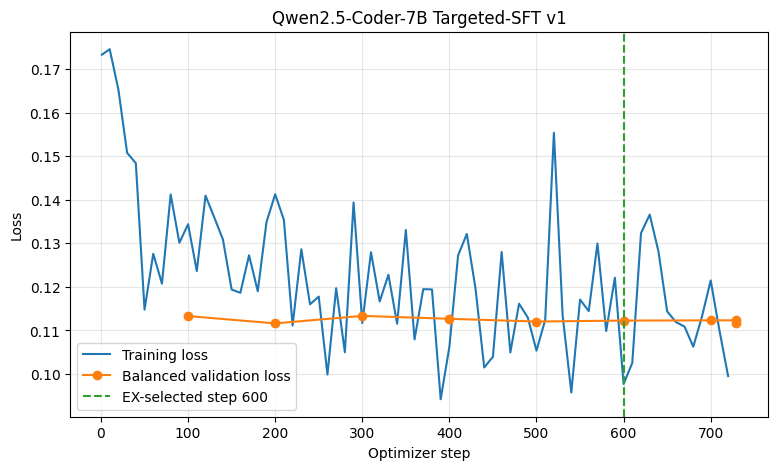

In [ ]:
train_log = history_df.dropna(subset=["loss"])
eval_log = history_df.dropna(subset=["eval_loss"])

plt.figure(figsize=(9, 5))

if not train_log.empty:
    plt.plot(train_log["step"], train_log["loss"], label="Training loss")

if not eval_log.empty:
    plt.plot(
        eval_log["step"],
        eval_log["eval_loss"],
        marker="o",
        label="Balanced validation loss",
    )

plt.axvline(
    selected_checkpoint_step,
    color="tab:green",
    linestyle="--",
    label=f"EX-selected step {selected_checkpoint_step}",
)
plt.xlabel("Optimizer step")
plt.ylabel("Loss")
plt.title("Qwen2.5-Coder-7B Targeted-SFT v1")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 17. Run a smoke test with the EX-selected Targeted-SFT adapter

This loads `final_adapter` explicitly, so the smoke test cannot silently use the
different minimum-loss checkpoint.


In [ ]:
SMOKE_ADAPTER_NAME = "targeted_ex_selected_final"
trainer.model.load_adapter(
    str(ADAPTER_DIR),
    adapter_name=SMOKE_ADAPTER_NAME,
    is_trainable=False,
)
trainer.model.set_adapter(SMOKE_ADAPTER_NAME)
trainer.model.eval()
trainer.model.config.use_cache = True

smoke_example = validation_dataset[0]
prompt_messages = smoke_example["messages"][:-1]
gold_sql = smoke_example["messages"][-1]["content"]

model_inputs = tokenizer.apply_chat_template(
    prompt_messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
).to(trainer.model.get_input_embeddings().weight.device)

with torch.inference_mode():
    generated_ids = trainer.model.generate(
        **model_inputs,
        max_new_tokens=256,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        use_cache=True,
    )

new_tokens = generated_ids[0, model_inputs["input_ids"].shape[1]:]
predicted_text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

print("Selected checkpoint:", selected_checkpoint)
print("Database ID:", smoke_example["db_id"])
print("Evidence condition:", smoke_example["use_evidence"])
print()
print("Predicted text:")
print(predicted_text)
print()
print("Gold SQL:")
print(gold_sql)


## Completion checklist and next step

Targeted-SFT training is complete only when:

- manifest hashes, 65/35 sampling, family weights, and evidence policy pass;
- training/general-validation database and source overlap is zero;
- the prompt count matches Original SFT and no record exceeds 8,192 tokens;
- completion-only masking is verified;
- training finishes and step checkpoints remain available;
- `checkpoint_execution_summary.csv` selects the held-out macro-EX winner;
- `final_adapter` is byte-identical to that checkpoint;
- general and targeted diagnostic losses are saved for the selected adapter;
- the final smoke test explicitly uses the Targeted-SFT `final_adapter`.

Then evaluate this adapter with the existing MiniDev500 inference protocol. Keep the
Base + evidence and Original-SFT + evidence result files unchanged, and generate a new
Targeted-SFT + evidence result file. Report EX@1, Oracle@3/5, valid-SQL rate,
difficulty-level EX, paired improvements/regressions, and uncertainty. MiniDev500 is
development data; do not present it as an untouched final test after using it for design.
